# 2D MT inversion (1 anomaly, 1% noise)

**What this notebook does:** Runs 2D MT inversion with Sinkhorn OT data loss on synthetic data (one conductive anomaly, 1% Gaussian noise). It shows the **resistivity section** (true vs inverted) so you can see how well the model is recovered.

**Effect:** The inversion minimizes an OT-based data misfit and roughness; the final plot compares true and recovered log10(resistivity) sections.

In [ ]:
##
import torch
import numpy as np
import sys
sys.path.append('..')
from src.MTinv_2d import MT2DInverter

# ======================================================
# 0. Device
# ======================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
freqs = torch.logspace(0.5, -4, 20)
stations = torch.linspace(-15000, 15000, 31)
# 1. 垂向网格 (Vertical Grid, z) - 核心修改
# ==========================================
nza = 10
# 空气层：保持指数增长，越靠近地表越密
z_air = -np.logspace(np.log10(10), np.log10(50000), nza) # 10m 到 50km
z_air = np.flip(z_air) # 翻转，从-50km到-10m
z_air = np.append(z_air, 0) # 加上地表 0

# 浅层精细区 (0 - 5km)
n_shallow = 10
z_shallow = np.logspace(np.log10(100), np.log10(5000), n_shallow)

# 深部扩展区 (5km - 100km) - 解决底部虚假异常的关键
n_deep = 20
z_deep = np.logspace(np.log10(6000), np.log10(100000), n_deep)

z_sub = np.concatenate([z_shallow, z_deep])
zn = np.concatenate([z_air[:-1], np.array([0]), z_sub])

# ==========================================
# 2. 横向网格 (Horizontal Grid, y) - 核心修改
# ==========================================
# 中心区（关注区）
y_center = np.linspace(-10000, 10000, 21) 

# 两侧扩展区：向外指数稀疏，直到 ±100km (消除侧向边界反射)
y_left = -np.logspace(np.log10(11000), np.log10(50000), 10)
y_right = np.logspace(np.log10(11000), np.log10(50000), 10)
y_left = np.flip(y_left)

yn = np.concatenate([y_left, y_center, y_right])

print(f"新的网格统计:")
print(f" - 垂向第一层厚度: {zn[nza+1] - zn[nza]:.1f} m (原: 1000m)")
print(f" - 最大深度: {zn[-1]/1000:.1f} km (原: 50km)")
print(f" - 中心区横向分辨率: {y_center[1] - y_center[0]:.1f} m (原: 1000m)")
print(f" - 网格总数: {len(zn)-1} x {len(yn)-1}")

Running on cuda
新的网格统计:
 - 垂向第一层厚度: 100.0 m (原: 1000m)
 - 最大深度: 100.0 km (原: 50km)
 - 中心区横向分辨率: 1000.0 m (原: 1000m)
 - 网格总数: 40 x 40


✓ 随机种子已设置: 123
✓ 创建Sinkhorn损失:
  - p范数: 2
  - blur: 0.01
  - scaling: 0.9
  - reach: None (平衡/强约束)
✓ Sinkhorn OT Loss 初始化成功
正在生成二维 MT 合成数据...
✓ XY 模式误差传播完成
   ρ(log10) 噪声均值: 0.0087
   φ(归一化) 噪声均值: 0.0064
✓ YX 模式误差传播完成
   ρ(log10) 噪声均值: 0.0087
   φ(归一化) 噪声均值: 0.0064
✓ 二维数据误差传播全部完成
正在计算数据权重 (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ 合成数据生成完成
  → 阻抗噪声水平: 1.0%
✓ 模型初始化完成: Uniform initialization.


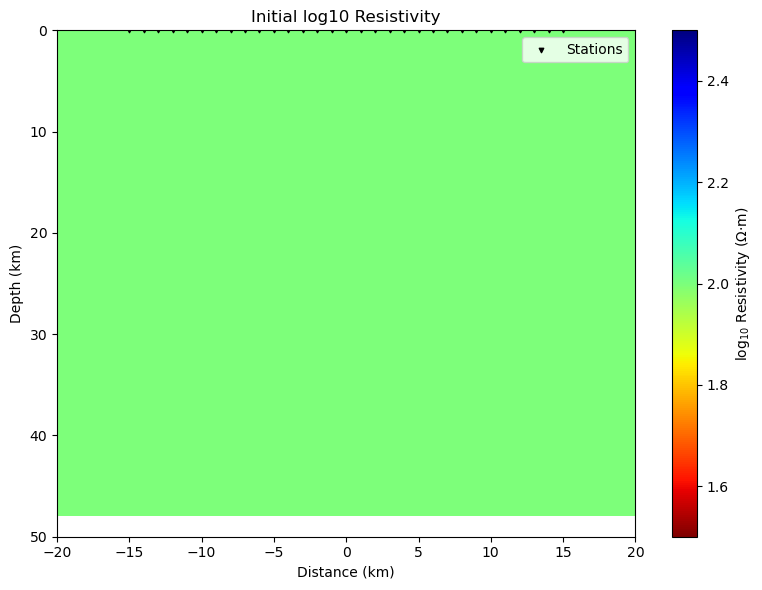

✓ 创建优化器: AdamW
  - 学习率: 0.05
  - 权重衰减: 0.0
✓ 跳过灵敏度权重计算 (使用单位权重 1.0)
Epoch 000/500 [  0.2%]
  已用时间: 0:00:06 | 剩余时间: ~0:47:56 | ETA: 22:48:43
  Epoch耗时: 5.76s | 平均耗时: 5.76s
  Total: 8.0516e-01 | Data(3dot): 8.0516e-01
  Misfit(RMS χ²): 21.388 | Rough: 0.00e+00 | Lam: 0.0100000
  GradNorms: |g_d|=2.315e-01 | |g_m|=1.000e-12
--------------------------------------------------------------------------------
Epoch 010/500 [  2.2%]
  已用时间: 0:00:47 | 剩余时间: ~0:34:52 | ETA: 22:36:20
  Epoch耗时: 4.12s | 平均耗时: 4.28s
  Total: 3.1004e-01 | Data(3dot): 2.5819e-01
  Misfit(RMS χ²): 15.847 | Rough: 1.04e+01 | Lam: 0.0049914
  GradNorms: |g_d|=3.520e-02 | |g_m|=4.313e+00
--------------------------------------------------------------------------------
Epoch 020/500 [  4.2%]
  已用时间: 0:01:29 | 剩余时间: ~0:33:43 | ETA: 22:35:53
  Epoch耗时: 4.33s | 平均耗时: 4.22s
  Total: 2.5374e-01 | Data(3dot): 1.7567e-01
  Misfit(RMS χ²): 15.172 | Rough: 2.42e+01 | Lam: 0.0032280
  GradNorms: |g_d|=4.054e-02 | |g_m|=5.792e+00
-----

In [3]:
# ======================================================
# 2. 构建真实模型
# ======================================================
yc = (yn[:-1] + yn[1:]) / 2.0
zc = (zn[:-1] + zn[1:]) / 2.0
Y, Z = np.meshgrid(yc, zc)

sig_true = np.ones_like(Y) * 0.01
sig_true[Z < 0] = 1e-9

mask_anomaly = (np.abs(Y) < 3000) & (Z > 5000) & (Z < 10000)
sig_true[mask_anomaly] = 1.0

sig_true = torch.tensor(sig_true, dtype=torch.float64, device=device)

# ======================================================
# 3. 初始化反演器（新接口）
# ======================================================
inverter = MT2DInverter(
    yn=torch.tensor(yn, device=device),
    zn=torch.tensor(zn, device=device),
    freqs=freqs.to(device),
    stations=stations.to(device),
    device=device,
    random_seed=123,
    sinkhorn_reach = None
)
# ===============================================
# 4. 设置正演算子
# ===============================================
inverter.set_forward_operator(nza=nza)

# ===============================================
# 5. 设置真实模型 & 生成 1% 噪声合成数据
# ===============================================
inverter.sig_true = sig_true
inverter.create_synthetic_data(noise_level=0.01)

# 6. 初始化反演模型
# ===============================================
inverter.initialize_model(initial_sigma=0.01)
inverter.plot_initial_model()
# ===============================================
# 7. 运行反演
# ======================================================
final_sigma = inverter.run_inversion(
    n_epochs=500,
    mode="3dot",
    progress_interval=10,
    current_lambda=0.01,
    use_adaptive_lambda=True,
    loss_data_ratio=100.0,
    lr=0.05,
    norm_type="L2",
)

# ======================================================
# 8. 结果
# ======================================================
print("反演完成，最终模型范围:")
print(final_sigma.min().item(), final_sigma.max().item())


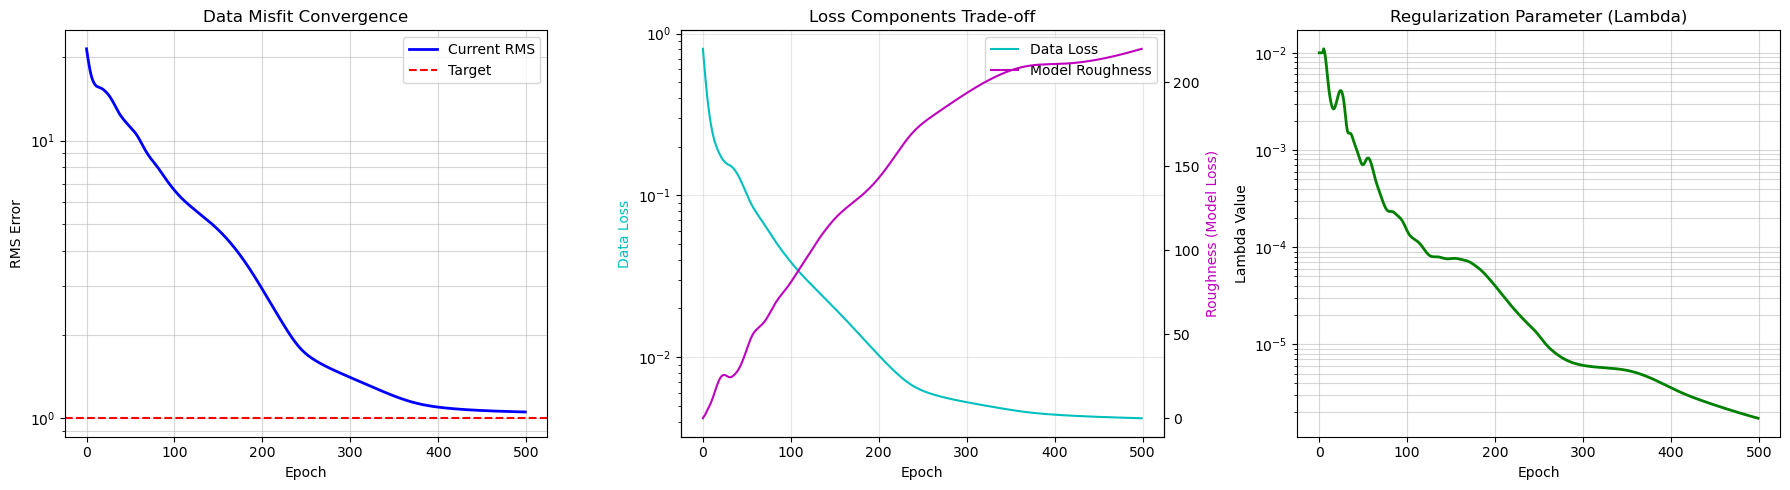

模型结构相似度 (SSIM): 0.7521


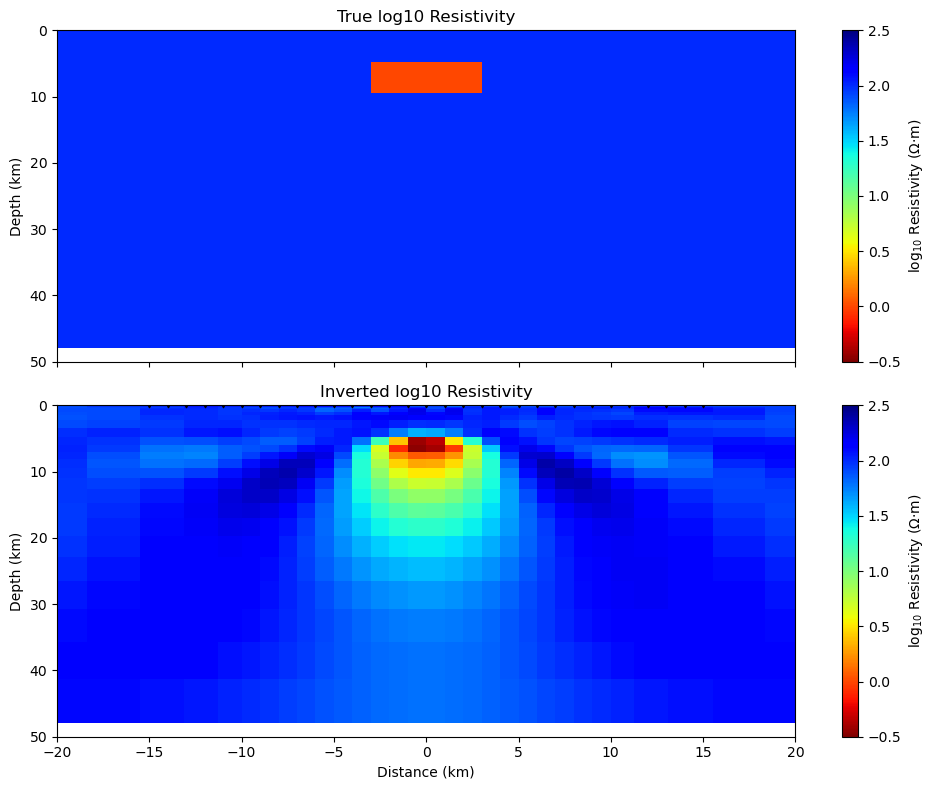

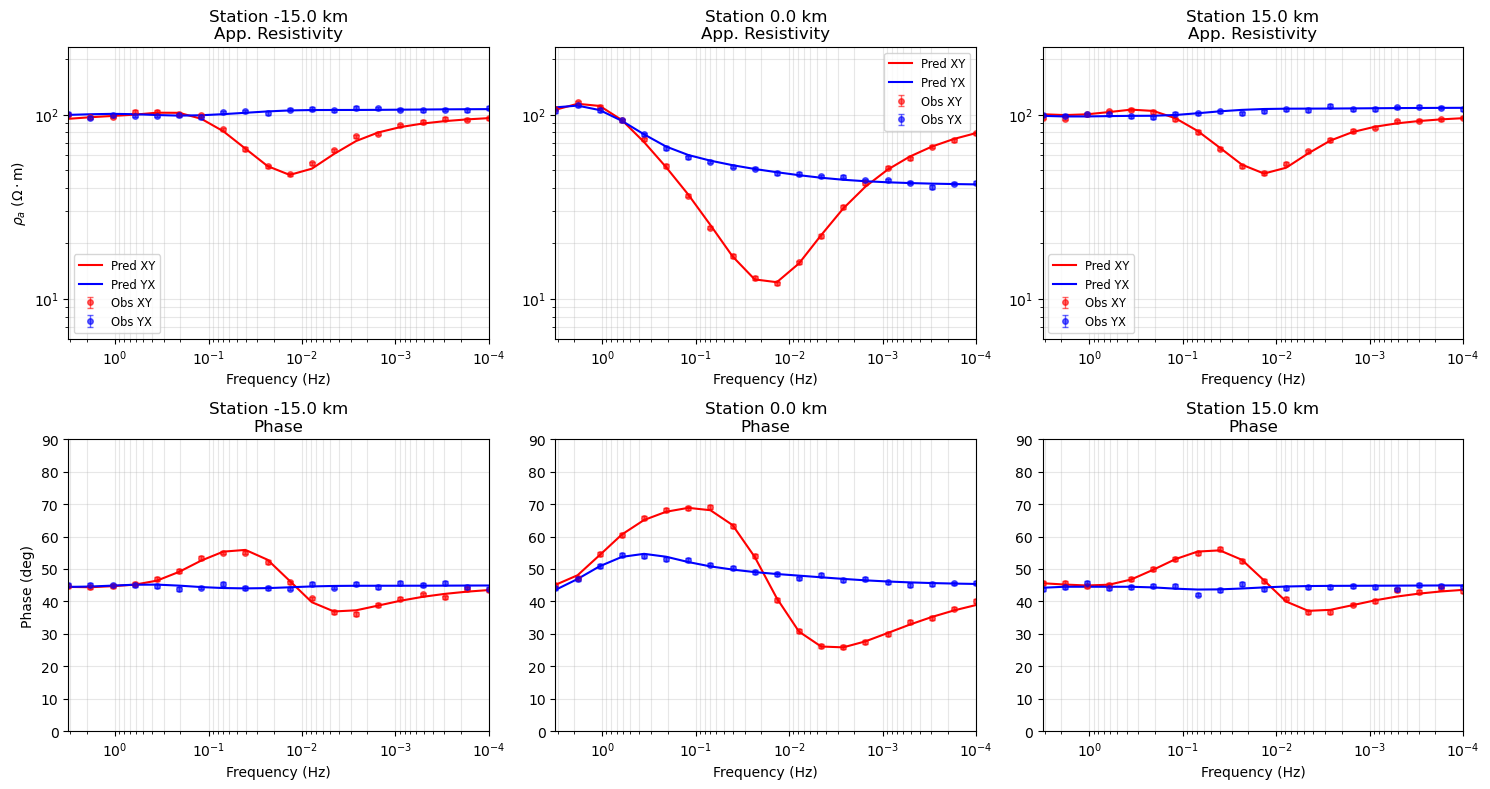

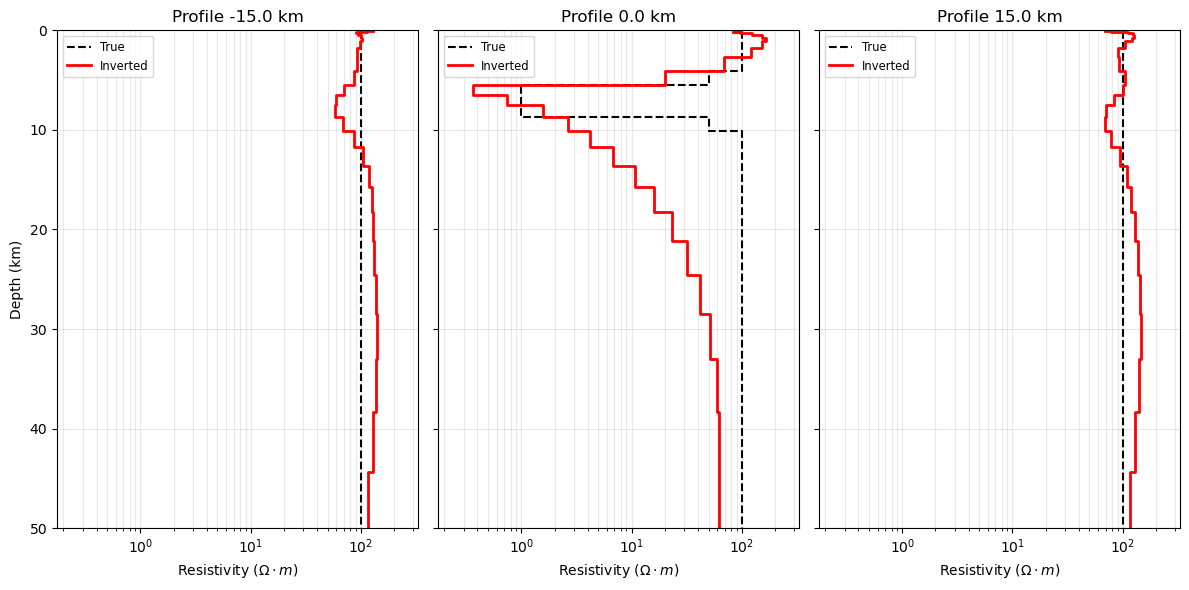

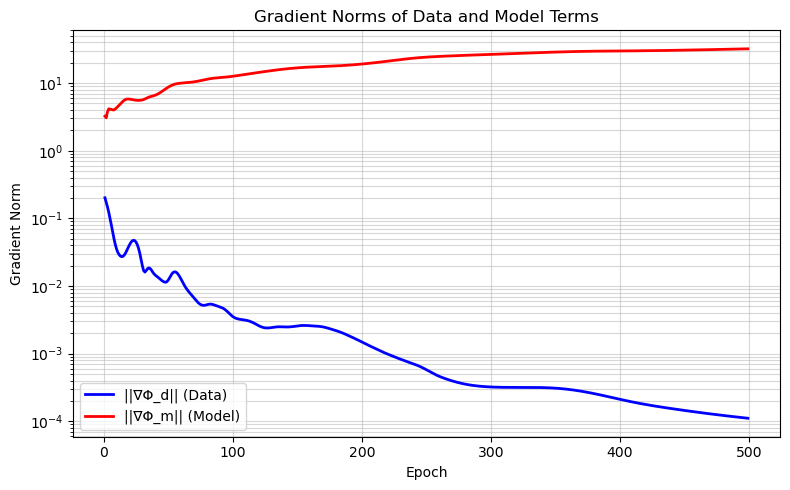

In [4]:
inverter.plot_loss_history()
inverter.plot_model_comparison(use_resistivity=True, cmap="jet_r", xlim=[-20, 20], ylim=[50, 0])
inverter.plot_data_fitting()
inverter.plot_1d_profiles(depth_limit_km = 50)
inverter.plot_gradient_history()